In [25]:
!pip install awkward

# **IMPORTING LIBRARIES**

In [26]:
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pad_sequence  # http://pytorch.org/docs/stable/generated/torch.nn.utils.rnn.pad_sequence.html
import time
import sys
import os
import argparse
import io
from datetime import datetime
import copy
import numpy as np
import awkward
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from matplotlib import pyplot as plt
import torch.nn.functional as F
#from torch_geometric.data import Data, Batch

# **USEFUL FUNCTIONS**

In [27]:
def compute_stats(dataset):
    data = dataset["data"]
    times, x, y = data[:, 0, :], data[:, 1, :], data[:, 2, :]
    return {
        "t_mean": awkward.mean(times), "t_std": awkward.std(times),
        "x_mean": awkward.mean(x), "x_std": awkward.std(x),
        "y_mean": awkward.mean(y), "y_std": awkward.std(y),
        "xpos_mean": awkward.mean(dataset["xpos"]), "xpos_std": awkward.std(dataset["xpos"]),
        "ypos_mean": awkward.mean(dataset["ypos"]), "ypos_std": awkward.std(dataset["ypos"]),
    }

In [28]:
def normalize_dataset(dataset, stats):
    times = dataset["data"][:, 0:1, :]
    x = dataset["data"][:, 1:2, :]
    y = dataset["data"][:, 2:3, :]

    norm_times = (times - stats["t_mean"]) / stats["t_std"]
    norm_x = (x - stats["x_mean"]) / stats["x_std"]
    norm_y = (y - stats["y_mean"]) / stats["y_std"]

    dataset["data"] = awkward.concatenate([norm_times, norm_x, norm_y], axis=1)
    dataset["xpos"] = (dataset["xpos"] - stats["xpos_mean"]) / stats["xpos_std"]
    dataset["ypos"] = (dataset["ypos"] - stats["ypos_mean"]) / stats["ypos_std"]
    return dataset

In [29]:
def denormalize_positions(preds, labels, stats):
    preds, labels = preds.copy(), labels.copy()
    preds[:, 0]  = preds[:, 0]  * stats["xpos_std"] + stats["xpos_mean"]
    preds[:, 1]  = preds[:, 1]  * stats["ypos_std"] + stats["ypos_mean"]
    labels[:, 0] = labels[:, 0] * stats["xpos_std"] + stats["xpos_mean"]
    labels[:, 1] = labels[:, 1] * stats["ypos_std"] + stats["ypos_mean"]
    return preds, labels

In [30]:
def collate_fn_transformer(batch: list[dict]) -> tuple[list[list | torch.Tensor], torch.Tensor]:
    """
    Custom function that defines how batches are formed.

    To process the batch items that each have a different number of hits, it is efficient
    to first concatenate all the data into a single tensor and save the lengths of each
    individual event to be able to split the data again later.

    # F: input_dim, number of features (time, x, y)
    # N: number of hits (different for each event)
    # B: batch size

    The resulting 2D tensor has the shape (B x N, F) where B is the batch size, N is the total number of hits of all events
    in the batch, and F is the number of features (time, x, y).


    Parameters
    ----------
    batch : list
        A list of dictionaries containing the data and labels for each graph.
        The data is available in the "data" key and the labels are in the "xpos" and "ypos" keys.
    Returns
    -------
    packed_data : Batch
        A batch of graph data objects.
    labels : torch.Tensor
        A tensor containing the labels for each graph.
    """
    data_list: list[torch.Tensor] = []
    labels: list[torch.Tensor] = []
    lengths: list[int] = []

    for b in batch:
        # this is a loop over each event within the batch
        # b["data"] is the first entry in the batch with dimensions (n_features, n_hits)
        # where the features are (time, x, y)
        tensor_data = torch.from_numpy(b["data"].to_numpy()).T
        # the original data is in double precision (float64), for our case single precision is sufficient
        # we let's convert to single precision (float32) to save memory and computation time
        tensor_data = tensor_data.to(dtype=torch.float32)

        lengths.append(tensor_data.shape[0])

        data_list.append(tensor_data)

        # also the labels need to be packaged as pytorch tensors
        labels.append(torch.Tensor([b["xpos"], b["ypos"]]).unsqueeze(0))

    ## return a list [data_list, lengths]
    return [
        torch.cat(data_list),  # (B, N, F)  -> (BxN, F) where B is the batch size, N is the number of hits, and F is the number of features (time, x, y)
        lengths,
    ], torch.cat(labels, dim=0)

In [31]:
def train_model_transformer(model, train_loader, val_loader, epochs, lr, patience, device, model_name="transformer_neutrino"):

    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    criterion = nn.MSELoss()

    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    patience_counter = 0
    best_model = None

    for epoch in range(epochs):
      start_time = time.time()

      # --- Training phase ---
      model.train()
      train_loss = 0.0

      for step, (transformer_input, batch_labels) in enumerate(train_loader):
        src_tensor, lengths_list = transformer_input
        src_tensor = src_tensor.to(device)
        batch_labels = batch_labels.to(device)

        optimizer.zero_grad()

        # Forward
        predictions = model((src_tensor, lengths_list))

        loss = criterion(predictions, batch_labels)

        # Backward pass
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        # Print loss every 10 steps
        if (step + 1) % 10 ==0:
          sys.stdout.write(f"\rEpoch {epoch+1}/{epochs} - Step {step+1}/{len(train_loader)} - Loss: {loss.item():.4f}")
          sys.stdout.flush()

      sys.stdout.write("\n")

      # --- VALIDATION PHASE ---
      model.eval()
      total_val_loss = 0.0

      with torch.no_grad():
        for transformer_input, batch_labels in val_loader:
          src_tensor, lengths_list = transformer_input
          src_tensor = src_tensor.to(device)
          batch_labels = batch_labels.to(device)

          predictions = model((src_tensor, lengths_list))
          val_loss = criterion(predictions, batch_labels)
          total_val_loss += val_loss.item()

      avg_train_loss = train_loss / len(train_loader)
      avg_val_loss = total_val_loss / len(val_loader)

      train_losses.append(avg_train_loss)
      val_losses.append(avg_val_loss)

      epoch_time = time.time() - start_time
      print(f"Epoch [{epoch + 1}/{epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Time: {epoch_time:.2f} s")

      # --- EARLY STOPPING ---
      if avg_val_loss < best_val_loss:
          best_val_loss = avg_val_loss
          patience_counter = 0

          best_model = copy.deepcopy(model.state_dict())

          if not os.path.exists('models'):
              os.makedirs('models')
          if model_name is not None:
              torch.save(best_model, f"models/{model_name}_best.pth")
      else:
          patience_counter += 1
          if patience_counter >= patience:
              print(f"Early stopping at epoch {epoch + 1}!")
              break

    if best_model is not None:
        model.load_state_dict(best_model)

    return train_losses, val_losses, model


In [32]:
def evaluate_model_transformer(model, test_loader, device):
  print("Evaluating model...")
  model.eval()

  criterion = nn.MSELoss()
  test_loss = 0.0

  all_predictions = []
  all_true_labels = []
  with torch.no_grad():
    for transformer_input, batch_labels in test_loader:
      src_tensor, lengths_list = transformer_input
      src_tensor = src_tensor.to(device)
      batch_labels = batch_labels.to(device)


      predictions = model((src_tensor, lengths_list))

      loss = criterion(predictions, batch_labels)
      test_loss += loss.item()

      all_predictions.append(predictions.cpu())
      all_true_labels.append(batch_labels.cpu())

  avg_test_loss = test_loss / len(test_loader)
  print(f"Final Test Loss (MSE): {avg_test_loss:.4f}")

  #Concatenating results into a single NUmpy array to manage them for plots
  all_predictions = torch.cat(all_predictions, dim=0).numpy()
  all_true_labels = torch.cat(all_true_labels, dim=0).numpy()

  return avg_test_loss, all_predictions, all_true_labels

In [33]:
def plot_loss(train_losses, val_losses):
  plt.figure(figsize=(10, 6))
  plt.plot(range(1, len(train_losses) + 1), train_losses, label='Training Loss', color = 'royalblue')
  plt.plot(range(1, len(val_losses) + 1), val_losses, label='Validation Loss', color = 'orange')
  plt.xlabel('Epoch')
  plt.ylabel('MSE Loss')
  plt.title('Training and Validation Loss')
  plt.legend()
  plt.grid(True, alpha=0.5, linestyle='--')
  plt.show()

In [34]:
def plot_scatter(x_pred, y_pred, x_true, y_true):
  plt.figure(figsize=(12,5))
  plt.subplot(1,2,1)
  plt.scatter(x_true, x_pred, s=10, alpha=0.4, color='royalblue')
  min_val_x, max_val_x = np.min(x_true), np.max(x_true)
  plt.plot([min_val_x, max_val_x], [min_val_x, max_val_x], '--', color = 'midnightblue', label = 'Perfect prediction')
  plt.xlabel("True x")
  plt.ylabel("Predicted x")
  plt.grid(True, alpha=0.5, linestyle='--')
  plt.legend()
  plt.subplot(1,2,2)
  plt.scatter(y_true, y_pred, s=10, alpha=0.4, color='limegreen')
  min_val_y, max_val_y = np.min(y_true), np.max(y_true)
  plt.plot([min_val_y, max_val_y], [min_val_y, max_val_y], '--', color = 'darkgreen', label = 'Perfect prediction')
  plt.xlabel("True y")
  plt.ylabel("Predicted y")
  plt.grid(True, alpha=0.5, linestyle='--')
  plt.legend()
  plt.tight_layout()
  plt.show()

In [35]:
def plot_residuals(x_pred, y_pred, x_true, y_true):
  residuals_x = x_pred - x_true
  residuals_y = y_pred - y_true
  plt.figure(figsize=(12,5))
  plt.subplot(1,2,1)
  plt.hist(residuals_x, bins=60, alpha=0.6, label='Residual on X', color='royalblue', edgecolor = 'royalblue')
  plt.axvline(0, color='midnightblue', linestyle='dashed', linewidth=1, label = 'Best prediciton')
  plt.xlabel('Residual (Predicted - Real) [m]')
  plt.ylabel('Counts')
  plt.legend()
  plt.grid(True, alpha=0.5, linestyle='--')
  plt.subplot(1,2,2)
  plt.hist(residuals_y, bins=60, alpha=0.6, label='Residual on Y', color='limegreen', edgecolor = 'limegreen')
  plt.axvline(0, color='darkgreen', linestyle='dashed', linewidth=1, label = 'Best prediciton')
  plt.xlabel('Residual (Predicted - Real) [m]')
  plt.ylabel('Counts')
  plt.legend()
  plt.grid(True, alpha=0.5, linestyle='--')
  plt.tight_layout()
  plt.show()

# **THE MODEL**

In [36]:
class TransformerEncoder(nn.Module):
    def __init__(
        self,
        input_dim = 3,      #input features: time, x, y
        d_model = 128,         #internal transoformer dimension
        nhead = 4,         #number of head attention
        num_layers = 3,       #number of layers
        dim_feedforward = 256,  #feedforward dimension
        output_dim = 2      #predicted features x, y
    ) -> None:
        super().__init__()
        self.input_embedding = nn.Linear(input_dim, d_model)
        encoder_layer = nn.TransformerEncoderLayer(  # https://pytorch.org/docs/stable/generated/torch.nn.TransformerEncoderLayer.html
            d_model=d_model,
            nhead= nhead,
            dim_feedforward=dim_feedforward,
            activation="relu",
            batch_first=True,      # to have batch as first dimension in the tensors
            norm_first=True,       # pre-layer normalization for stability
            dropout=0.02
        )


        self.encoder = nn.TransformerEncoder(
                    encoder_layer,
                    num_layers= num_layers
                )  # https://pytorch.org/docs/stable/generated/torch.nn.TransformerEncoder.html

        self.output_layer = nn.Sequential(
            nn.Linear(d_model, d_model // 2),     # using // so that you get an int as output
            nn.ReLU(),
            nn.Linear(d_model // 2, output_dim)
        )
    def forward(self, data: tuple[torch.Tensor, list[int]]) -> torch.Tensor:
        """
        Args:
            data: list of (src tensor, lengths)
        Returns:
            Tensor of shape (batch, output_dim)
        """

        src, lengths = data

        # F: input_dim, number of features (time, x, y)
        # N: number of hits
        # D: hidden_dim, internal transformer computing dimension
        # B: batch size

        # 1) embed the input data into the hidden dimension
        src = self.input_embedding(src)  # shape (B x N, F) -> (B x N, D)

        # 2) split the data into a list of tensors, one for each event
        parts = src.split(lengths, dim=0)  # shape (B x N, D) -> (B, N, D), where every batch entry can have a variable length,
        # i.e., list of tensors of shape (N_i, D) where N_i is the number of hits in the i-th event

        # 3) pad inputs with zeros so that all batch items have same length
        padded = pad_sequence(parts, batch_first=True)  # shape (B, N, D) -> (B x MAXLEN x D) now all batch entries have the same length
        batch_size, max_len, _ = padded.shape

        # 4) build the padding mask (batch_size, max_len)
        # we need to keep track which tokens are padding tokens and which are real tokens
        # the mask is a boolean tensor of shape (B, MAXLEN) where True indicates that the corresponding entry is a padding token
        # and False indicates that the corresponding entry is a real token
        # the mask is used to ignore the padding tokens in the attention mechanism
        mask = torch.zeros(batch_size, max_len, dtype=torch.bool).to(device=padded.device, dtype=torch.bool)
        for i, L in enumerate(lengths):
            mask[i, L:] = True

        # 5) call the transformer with padded tensor of shape (B, MAXLEN, D) and corresponding mask of shape (B, MAXLEN)
        enc_out = self.encoder(padded, src_key_padding_mask=mask)

        # 6) masked mean‐pool, i.e., form the average for every batch item along the sequence dimension
        # the output of the transformer is a tensor of shape (B, MAXLEN, D)
        # we need to take the mean over the sequence dimension (MAXLEN) to get a single vector for each batch item
        # we need to ignore the padding tokens in the mean pooling
        # the resulting shape is (B, D)
        valid_mask = ~mask
        summed = (enc_out * valid_mask.unsqueeze(-1)).sum(dim=1)
        pooled = summed / torch.LongTensor(lengths)[:, None].to(enc_out)

        # 7) apply a final linear layer to get the output of shape (B, output_dim)
        out = self.output_layer(pooled)

        return out


# **DATA LOADING**

In [37]:
from google.colab import drive
drive.mount('/content/drive')
sys.path.append('/content/drive/My Drive/Colab Notebooks/Advanced Deep Learning TU Dortmund/TRANSFORMERS')
DATA_PATH = '/content/drive/My Drive/Colab Notebooks/Advanced Deep Learning TU Dortmund/TRANSFORMERS/IceCube 2D Dataset/'

# Load the dataset
train_dataset = awkward.from_parquet(os.path.join(DATA_PATH, "train.pq"))
val_dataset = awkward.from_parquet(os.path.join(DATA_PATH, "val.pq"))
test_dataset = awkward.from_parquet(os.path.join(DATA_PATH, "test.pq"))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [38]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [39]:
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn_transformer)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn_transformer)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn_transformer)

# **HYPERPARAMETERS**

In [40]:
learning_rate = 1e-4
num_epochs = 100
patience = 30

In [41]:
model = TransformerEncoder().to(device)

/tmp/ipykernel_4453/1321952985.py:24: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


# **Feature and Label Normalization**
Here we normalize the Hit features (`t`, `x`, `y`) and position labels (`xpos`, `ypos`) with the z-score:
$$\frac{x - \mu_x}{\sigma_x}$$
Mean and std are computed **only on the training set** and reused to normalize validation and
test sets.

In [42]:
stats = compute_stats(train_dataset)
train_dataset = normalize_dataset(train_dataset, stats)
val_dataset   = normalize_dataset(val_dataset, stats)
test_dataset  = normalize_dataset(test_dataset, stats)

# **TRAINING PHASE**

In [43]:
train_losses, val_losses, best_model = train_model_transformer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=num_epochs,
    lr = learning_rate,
    patience=patience,
    device=device,
    model_name="transformer_neutrino"
)

Epoch 1/100 - Step 70/79 - Loss: 0.1831
Epoch [1/100], Train Loss: 0.4731, Val Loss: 0.1994, Time: 25.53 s
Epoch 2/100 - Step 70/79 - Loss: 0.1107
Epoch [2/100], Train Loss: 0.1535, Val Loss: 0.1414, Time: 15.90 s
Epoch 3/100 - Step 70/79 - Loss: 0.1308
Epoch [3/100], Train Loss: 0.1187, Val Loss: 0.1136, Time: 15.95 s
Epoch 4/100 - Step 70/79 - Loss: 0.1447
Epoch [4/100], Train Loss: 0.1022, Val Loss: 0.0999, Time: 15.67 s
Epoch 5/100 - Step 70/79 - Loss: 0.0937
Epoch [5/100], Train Loss: 0.0939, Val Loss: 0.0996, Time: 15.98 s
Epoch 6/100 - Step 70/79 - Loss: 0.1030
Epoch [6/100], Train Loss: 0.0888, Val Loss: 0.0927, Time: 18.77 s
Epoch 7/100 - Step 70/79 - Loss: 0.0635
Epoch [7/100], Train Loss: 0.0852, Val Loss: 0.0918, Time: 16.01 s
Epoch 8/100 - Step 70/79 - Loss: 0.0660
Epoch [8/100], Train Loss: 0.0826, Val Loss: 0.0912, Time: 16.09 s
Epoch 9/100 - Step 70/79 - Loss: 0.0579
Epoch [9/100], Train Loss: 0.0801, Val Loss: 0.0896, Time: 15.83 s
Epoch 10/100 - Step 70/79 - Loss: 0.0

# **EVALUATION PHASE**

In [44]:
test_loss, all_predictions, all_true_labels = evaluate_model_transformer(best_model, test_loader, device)

Evaluating model...
Final Test Loss (MSE): 0.0761


# **DDENORMALIZING**

In [45]:
all_predictions, all_true_labels = denormalize_positions(all_predictions, all_true_labels, stats)

# **PLOTS**

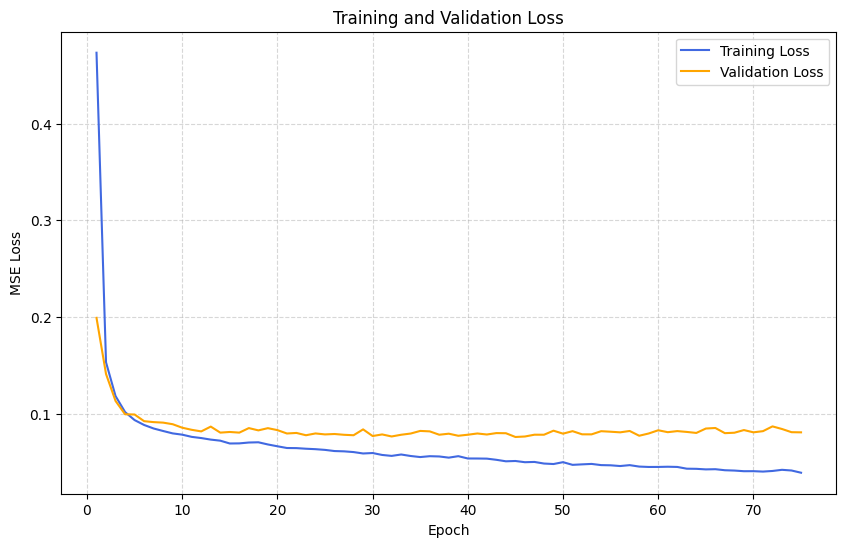

In [46]:
plot_loss(train_losses, val_losses)

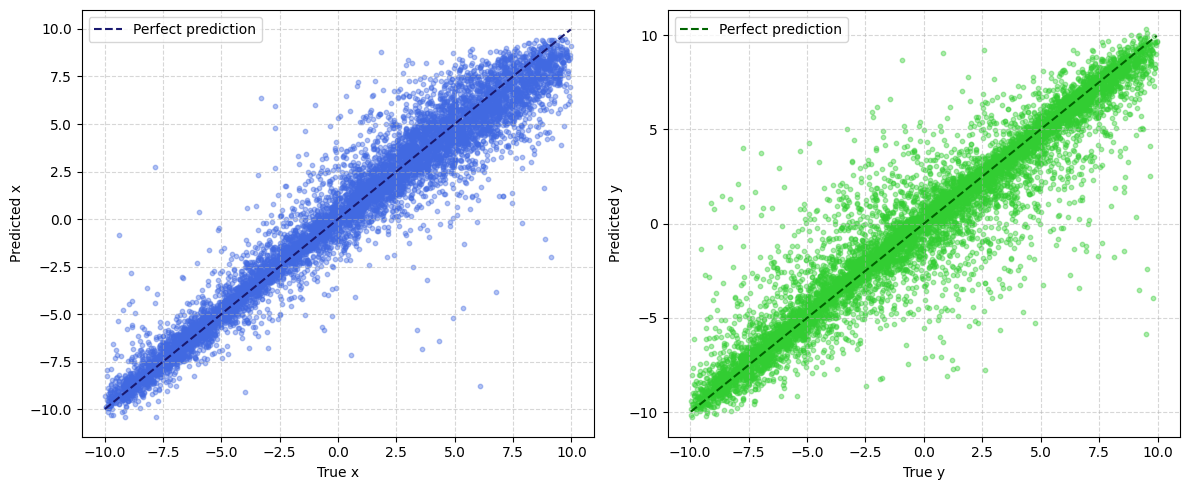

In [47]:
plot_scatter(all_predictions[:,0], all_predictions[:,1], all_true_labels[:,0], all_true_labels[:,1])


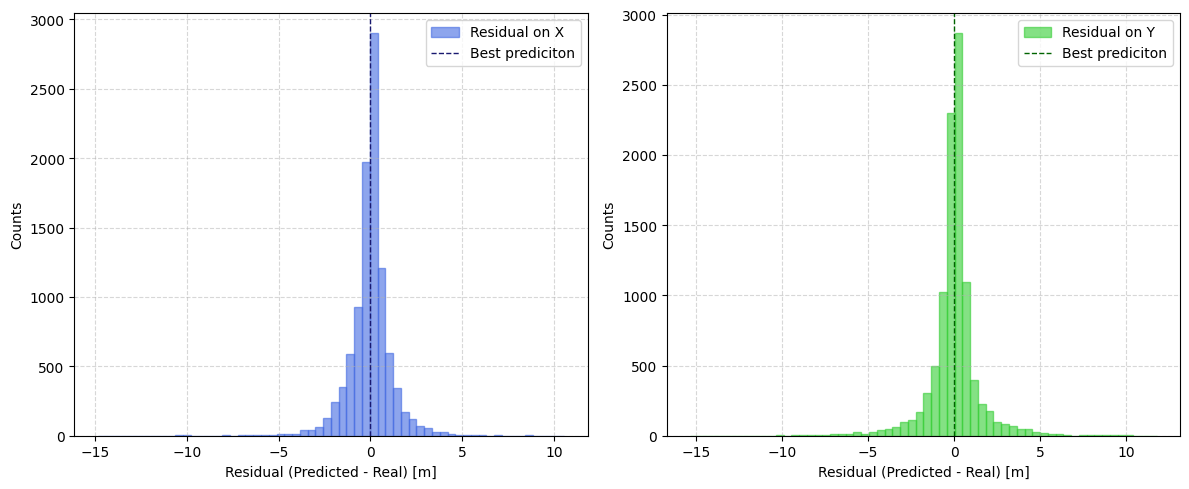

In [48]:
plot_residuals(all_predictions[:,0], all_predictions[:,1], all_true_labels[:,0], all_true_labels[:,1])